In [1]:

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import torch as tn
import random
import warnings
import multiprocessing as mp
from functools import partial
from scipy.integrate import quad, IntegrationWarning
import time
from datetime import date, time, datetime
from concurrent.futures import ThreadPoolExecutor


# Import files
from rotation import*
from functions import  d_sigma, d_sigma_sm, sigma_sm, sme, sigma_full, summation_terms, integrate_sigma_hat_prime_sm, integrate_sigma_hat_prime_sme, dsigma_dQ, dsigma_dQ_1,dsigma_dQ_2,dsigma_dQ_3
from constants import *
from math import sqrt

LHAPDF 6.5.4 loading /home/submit/jbenke/miniforge3/envs/liv-sme/share/LHAPDF/NNPDF31_nnlo_as_0118/NNPDF31_nnlo_as_0118_0000.dat
NNPDF31_nnlo_as_0118 PDF set, member #0, version 1; LHAPDF ID = 303600


In [2]:

# Quarks
quarks = [
    (2, 2/3*e, 'u', 1/2),
     (1, -1/3*e, 'd', -1/2),
     (3, -1/3*e, 's', -1/2),
     # (4, 2/3*e, 'c', 1/2),
     #  (5, -1/3*e, 'b', -1/2),
     # (6, 2/3*e, 't', 1/2),
]

# List of quark properties and couplings
quark_couplings = []

for flavor, e_f, name, I3 in quarks:
    g_fR = -e_f * sin2th_w
    g_fL = I3 - e_f * sin2th_w
    
    # Rounding to 4 decimal places
    e_f = round(e_f, 10)
    g_fR = round(g_fR, 10)
    g_fL = round(g_fL, 10)
    
    quark_couplings.append((flavor, e_f, g_fR, g_fL))

print(quark_couplings)
quark_couplings1 = [(2, 0.2018666667, -0.046673592, 0.453326408)]
quark_couplings2 = [(1, -0.1009333333, 0.023336796, -0.476663204)]
#Don't foregt the metric convenction (+, -, -, -)
g = tn.tensor([
    [1,0,0,0],
    [0,-1,0,0],
    [0,0,-1,0],
    [0,0,0,-1]
], dtype=tn.float32)
CL1 = tn.tensor([
    [0, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, -1, 0],
    [0,0, 0, 0]
], dtype=tn.float32)
CL2 = tn.tensor([
    [0, 0, 0, 0],
    [0, 0, -1, 0],
    [0, -1, 0, 0],
    [0,0, 0, 0]
], dtype=tn.float32)
CL3 = tn.tensor([
    [0, 0, 0, 0],
    [0, 0, 0, -1],
    [0, 0, 0, 0],
    [0,-1, 0, 0]
], dtype=tn.float32)
CL4 = tn.tensor([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, -1],
    [0,0,-1, 0]
], dtype=tn.float32)

CLzz = tn.tensor([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0,0,0, -1]
], dtype=tn.float32)

CR = tn.tensor([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
], dtype=tn.float32)


[(2, 0.2018666667, -0.046673592, 0.453326408), (1, -0.1009333333, 0.023336796, -0.476663204), (3, -0.1009333333, 0.023336796, -0.476663204)]


In [3]:
# Define the constant tensors once
p1 =  tn.tensor([1, 0, 0, 1], dtype=tn.float32)
p2 =  tn.tensor([1, 0, 0, -1], dtype=tn.float32)

# Precompute total number of steps

specific_time = datetime(2017, 1, 1, 0, 0)

start_time = int(specific_time.timestamp())

# start_time = int(time.time())
end_time = start_time + int(timedelta(days=1).total_seconds())
step_seconds = int(timedelta(hours=1).total_seconds())
num_steps = (end_time - start_time) // step_seconds

# Lists to store the times and contr matrix elements
times = []
contrelep1 = []
contrelep2 = []

R_y_lat = R_y(latitude)
R_z_azi = R_z(azimuth)
mat_cons = tn.matmul(R_y_lat,R_z_azi)
# Main loop
current_time = start_time
for _ in range(num_steps):
    # Convert current_time to a timestamp
    current_datetime = datetime.fromtimestamp(current_time)
    time_utc = current_datetime.timestamp()

    # Calculate omega_t
    omega_t_sid = omega_utc * time_utc + 3.2830 
    # Construct the complete rotation matrix from SCF to CMS
    R_Z_omega = R_Z(omega_t_sid)
    R_mat = tn.matmul(R_Z_omega, mat_cons)
    R_matrix1 = tn.einsum('ma,an->mn', g, R_mat)
    R_matrix2 = tn.einsum('am,na->mn', g, R_mat)
    # print(R_matrix1)
    # Compute contrL and contrR using matrix multiplication
    contrp1 = tn.einsum('ij,j->i', R_matrix1, p1)
    contrp2 =  tn.einsum('ij,i->j',R_matrix2, p2)
    # Record the times and contr matrix elements
    times.append(current_time)
    contrelep1.append(contrp1)
    contrelep2.append(contrp2)


    # Move to the next time step
    current_time += step_seconds
 

In [4]:
%%time
warnings.simplefilter("ignore", IntegrationWarning)

def compute_sme_for_bin(Q_range):
    # Unpack the tuple
    Q_start, Q_end = Q_range
    # Function to compute SME for a given range
    return sme(Q_start, Q_end, CLzz, CR, p1, p2, quark_couplings1)

if __name__ == '__main__':
    Q_val = np.linspace(15, 120, 100)
    a = 15  # Start of the Q range
    b = 120  # End of the Q range
    nbins = 17  # Number of bins

    Q_bins = np.linspace(a, b, nbins + 1)

    # Prepare the list of arguments for each bin
    bin_ranges = [(Q_bins[i], Q_bins[i + 1]) for i in range(len(Q_bins) - 1)]

    # Use multiprocessing to compute SME values
    with mp.Pool() as pool:
        up_left = pool.map(compute_sme_for_bin, bin_ranges)


CPU times: user 47.8 ms, sys: 435 ms, total: 483 ms
Wall time: 2min 44s


In [5]:
%%time
warnings.simplefilter("ignore", IntegrationWarning)

def compute_sme_for_bin(Q_range):
    # Unpack the tuple
    Q_start, Q_end = Q_range
    # Function to compute SME for a given range
    return sme(Q_start, Q_end, CR, CL1, p1, p2, quark_couplings1)

if __name__ == '__main__':
    Q_val = np.linspace(15, 120, 100)
    a = 15  # Start of the Q range
    b = 120  # End of the Q range
    nbins = 17  # Number of bins

    Q_bins = np.linspace(a, b, nbins + 1)

    # Prepare the list of arguments for each bin
    bin_ranges = [(Q_bins[i], Q_bins[i + 1]) for i in range(len(Q_bins) - 1)]

    # Use multiprocessing to compute SME values
    with mp.Pool() as pool:
        up_right = pool.map(compute_sme_for_bin, bin_ranges)


CPU times: user 55.4 ms, sys: 557 ms, total: 612 ms
Wall time: 5.06 s


In [6]:
%%time
warnings.simplefilter("ignore", IntegrationWarning)

def compute_sme_for_bin(Q_range):
    # Unpack the tuple
    Q_start, Q_end = Q_range
    # Function to compute SME for a given range
    return sme(Q_start, Q_end, CLzz, CR, p1, p2, quark_couplings2)

if __name__ == '__main__':
    Q_val = np.linspace(15, 120, 100)
    a = 15  # Start of the Q range
    b = 120  # End of the Q range
    nbins = 17  # Number of bins

    Q_bins = np.linspace(a, b, nbins + 1)

    # Prepare the list of arguments for each bin
    bin_ranges = [(Q_bins[i], Q_bins[i + 1]) for i in range(len(Q_bins) - 1)]

    # Use multiprocessing to compute SME values
    with mp.Pool() as pool:
        down_left = pool.map(compute_sme_for_bin, bin_ranges)


CPU times: user 67.9 ms, sys: 668 ms, total: 736 ms
Wall time: 3min 15s


In [7]:
%%time
warnings.simplefilter("ignore", IntegrationWarning)

def compute_sme_for_bin(Q_range):
    # Unpack the tuple
    Q_start, Q_end = Q_range
    # Function to compute SME for a given range
    return sme(Q_start, Q_end, CR, CLzz, p1, p2, quark_couplings2)

if __name__ == '__main__':
    Q_val = np.linspace(15, 120, 100)
    a = 15  # Start of the Q range
    b = 120  # End of the Q range
    nbins = 17  # Number of bins

    Q_bins = np.linspace(a, b, nbins + 1)

    # Prepare the list of arguments for each bin
    bin_ranges = [(Q_bins[i], Q_bins[i + 1]) for i in range(len(Q_bins) - 1)]

    # Use multiprocessing to compute SME values
    with mp.Pool() as pool:
        down_right = pool.map(compute_sme_for_bin, bin_ranges)


CPU times: user 64.7 ms, sys: 761 ms, total: 826 ms
Wall time: 3min 15s


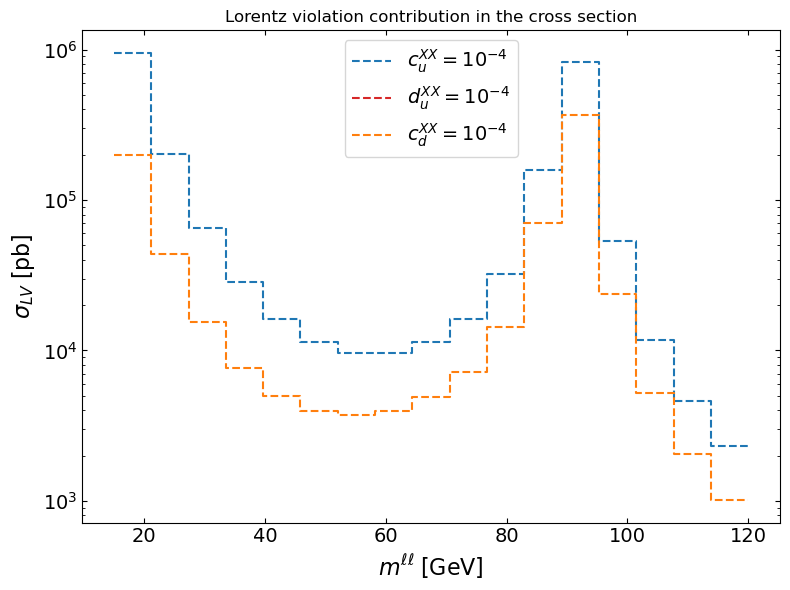

In [8]:
plt.figure(figsize=(8, 6))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

c_up = [up_right[i] + up_left[i] for i in range(len(up_left))]
d_up = [up_right[i] - up_left[i] for i in range(len(up_left))]
c_down = [down_right[i] + down_left[i] for i in range(len(up_left))]

# Create the step plot
plt.step(Q_bins, c_up + [c_up[-1]], where='post', color='tab:blue', linestyle='--', label = '$c^{XX}_{u}=10^{-4}$')
plt.step(Q_bins, d_up + [d_up[-1]], where='post', color='tab:red', linestyle='--', label = '$d^{XX}_{u}=10^{-4}$')
plt.step(Q_bins,  c_down + [c_down[-1]], where='post', color='tab:orange', linestyle='--', label = '$c^{XX}_{d}=10^{-4}$')

# plt.step(Q_bins, c_up + [c_up[-1]], where='post', color='C0', linestyle='--', label = '$c^{XX}_{u}=10^{-4}$')
# plt.step(Q_bins, d_up + [d_up[-1]], where='post', color='C1', linestyle='--', label = '$d^{XX}_{u}=10^{-4}$')
# plt.step(Q_bins,  c_down + [c_down[-1]], where='post', color='C2', linestyle='--', label = '$c^{XX}_{d}=10^{-4}$')



plt.xlabel('$m^{\ell \ell}\\;$[GeV]', fontsize = 16)
plt.yscale('log')
plt.ylabel('$\\sigma_{LV} \\;$[pb]', fontsize = 16)
plt.title('Lorentz violation contribution in the cross section')
# plt.grid(True, which="both", ls="--")  

plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.legend(fontsize=14, loc='best')
# Save and show the plot
plt.savefig('intrsec.png', dpi=300)
plt.show()
